In [ ]:
from core.utils import *
from core.datasetclass import *
import jax
import jax.numpy as jnp
import numpy as np
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
config.update("jax_enable_x64", True)

from core.material_models import get_material
# with install_import_hook("gpjax", "beartype.beartype"):
#     import gpjax as gpx
import gpjax as gpx
key = jr.key(123)


cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]
from flax import struct
from flax.serialization import to_state_dict, from_state_dict

In [ ]:
material_model = get_material("neo-hookean")
dataset = BenchmarkDataset("dataset/benchmarks", "noise=low", "NeoHookean")
data = dataset[20]

In [ ]:
F = data["F"]
invariants = data["invariants"]

In [ ]:
invariants

In [ ]:
coeffs = data["coeffs"]

In [ ]:
coeffs

In [ ]:
dpsi2 = - coeffs[:, 2]/2 * invariants[:, 2]**0.5

In [ ]:
dpsi2

In [ ]:
n_samples = 200
gamma_range = (1.0, 2.0)
dataset = []
mat_model = get_material("neo-hookean")
generators = [
              UniaxialGenerator(n_samples, gamma_range, None, 0.00, mat_model),
              BiaxialGenerator(n_samples, gamma_range, None, 0.00, mat_model),
              PureShearGenerator(n_samples, gamma_range, None, 0.00, mat_model)
              ]
F_list = []
invariants_list = []
sigma_list = []
coeffs_list = []
for gen in generators :
    f = gen.get_F()
    invariants = gen.get_invariants(f)
    sigma = gen.get_cauchy_stress(f)
    coeffs = gen.get_coeffs(f)
    F_list.append(f)
    invariants_list.append(invariants)
    coeffs_list.append(coeffs)
    sigma_list.append(sigma)

F_train = jnp.concat(F_list)
invariants_train = jnp.concat(invariants_list)
sigma_train = jnp.concat(sigma_list)
coeffs_train = jnp.concat(coeffs_list)

In [ ]:
coeffs_train

In [ ]:
coeffs_train.shape

# Define MultiOutput Independent GP

In [ ]:
class TensorBasisGPModel() :
    def __init__(self, train_x, train_y, means:list[gpx.mean_functions.Zero], kernels:list[gpx.kernels.RBF]) :
        self.number_gps = len(means)
        self.means = means
        self.kernels = kernels
        self.train_x = train_x
        self.train_y = train_y
        
        self.normalizer_x = MinMaxScaler()
        self.normalizer_x.fit(train_x)

        # self.normalizer_y = MinMaxScaler()
        # self.normalizer_y.fit(train_y)
        # norm_train_y = self.normalizer_y.transform(train_y)
        # creat prior from means and kernels
        self.datapoints = [gpx.Dataset(X = self.normalizer_x.transform(train_x), y = train_y[:, i, None]) for i in range(self.number_gps)]

        self.priors = [gpx.gps.Prior(mean_function=mean, kernel=kernel) for mean, kernel in zip(self.means, self.kernels)]
        self.likelihoods = [gpx.likelihoods.Gaussian(num_datapoints = self.datapoints[gp_idx].n, obs_stddev=jnp.array(0.1)) for gp_idx in range(self.number_gps)]
        
        self.posteriors = [prior * likelihood for prior, likelihood in zip(self.priors, self.likelihoods)]
        self.opt_posteriors = self.posteriors
    def optimize_hyperparameters(self):
        opt_posteriors = []
        histories = []
        for datapoint, posterior in zip(self.datapoints, self.posteriors) :
            opt_posterior, history = gpx.fit_scipy(
                model=posterior,
                objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
                train_data = datapoint,
                trainable=gpx.parameters.Parameter,
                safe = True
                )
            opt_posteriors.append(opt_posterior)
            histories.append(history)
        self.opt_posteriors = opt_posteriors
        return opt_posteriors, histories

    def save_model(self, save_path):
        os.makedirs(save_path, exist_ok=True)

        # Save model parameter dictionaries
        opt_posteriors_params_dict = to_state_dict(self.opt_posteriors)

        with open(os.path.join(save_path, "opt_posterior_params.json"), "w") as f:
            json.dump(opt_posteriors_params_dict, f)

    def load_model(self, model_path):
        
        with open(os.path.join(model_path, "opt_posterior_params.json"), "r") as f:
            opt_posterior_params_dict = json.load(f)

        # Restore parameters into objects
        self.posteriors = from_state_dict(self.opt_posteriors, opt_posterior_params_dict)

        # Rebuild posteriors
        self.opt_posteriors = self.posteriors


    def predict_coeffs(self, invariants) :
        norm_invariants = self.normalizer_x.transform(invariants)
        pred_means_list = []
        pred_stds_list = []
        for idx, opt_posterior in enumerate(self.opt_posteriors) :
            latent_dist = opt_posterior.predict(norm_invariants, self.datapoints[idx])
            predictive_dist = opt_posterior.likelihood(latent_dist)
            predictive_mean = predictive_dist.mean
            predictive_std = jnp.sqrt(predictive_dist.variance)
            pred_means_list.append(predictive_mean)
            pred_stds_list.append(predictive_std)
        pred_means = jnp.stack(pred_means_list, axis = -1)
        pred_stds = jnp.stack(pred_stds_list, axis = -1)
        return pred_means, pred_stds

    def predict_cauchy_stress(self, deformation_gradient):
        """
        Compute mean and std of the Cauchy stress given a deformation gradient F.
        F : (..., 3, 3)
        """

        # Left Cauchy–Green tensor b = F * F^T
        b = B_func(deformation_gradient)
        # Compute invariants I1, I2, I3
        invariants = jnp.stack([
            I1_func(b),
            I2_func(b),
            I3_func(b)
        ], axis=-1)   # shape (..., 3)
        # Predict distribution params for coefficients c1, c2, c3
        coeff_means, coeff_stds = self.predict_coeffs(invariants)

        # Means and stds (each coeff is a distribution)
        c_means = coeff_means
        c_stds  = coeff_stds

        c1, c2, c3 = c_means[..., 0], c_means[..., 1], c_means[..., 2]
        s1, s2, s3 = c_stds[..., 0], c_stds[..., 1], c_stds[..., 2]

        # Identity
        I = jnp.eye(3)

        # Cauchy stress mean
        sigma_mean = (
            c1[..., None, None] * I +
            c2[..., None, None] * b +
            c3[..., None, None] * (b @ b)
        )

        # Linearized uncertainty propagation
        sigma_std = (
            s1[..., None, None] * jnp.abs(I) +
            s2[..., None, None] * jnp.abs(b) +
            s3[..., None, None] * jnp.abs(b @ b)
        )

        return sigma_mean, sigma_std


In [ ]:
# kernels = [gpx.kernels.RationalQuadratic(active_dims=[0,1,2], lengthscale = [0.5, 0.1, 0.6],n_dims=3) + gpx.kernels.Linear(active_dims=[0,1,2], n_dims=3)] * 3 
kernels = [gpx.kernels.RBF(active_dims=[0,1,2], lengthscale = [0.5, 0.1, 0.6],n_dims=3) + gpx.kernels.Polynomial(active_dims=[0,1,2], degree = 2, n_dims=3)] * 3 
means = [gpx.mean_functions.Constant() for _ in range(3)]
train_x = invariants_train
train_y = coeffs_train

model = TensorBasisGPModel(train_x, train_y, means, kernels)

In [ ]:
opt_posteriors, _ = model.optimize_hyperparameters()

In [ ]:
opt_posteriors[0].prior

In [ ]:
opt_posteriors[0].prior.kernel.lengthscale

In [ ]:
coeffs_means, coeffs_stds = model.predict_coeffs(train_x)

In [ ]:
model.train_y.shape

In [ ]:
train_x.shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example: assume you already have
# input_x: shape (n,)
# coeffs_means: list of 3 arrays [mean1, mean2, mean3], each shape (n,)
# coeffs_stds:  list of 3 arrays [std1,  std2,  std3],  each shape (n,)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
t = 401
h = 600
for i, ax in enumerate(axes):
    mean = coeffs_means[:, i]
    std = coeffs_stds[:, i]
    lower = mean - 2 * std
    upper = mean + 2 * std
    ax.scatter(train_x[t:h, 0], model.train_y[t:h, i], marker = "x", color = "k")
    ax.plot(train_x[t:h, 0], mean[t:h], color="tab:blue", label=f"Coeff {i+1} mean")
    # ax.fill_between(train_x[t:h, 0], lower[t:h], upper[t:h], color="tab:blue", alpha=0.2, label="±2σ region")
    
    ax.set_ylabel(f"Coeff {i+1}")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.6)

axes[-1].set_xlabel("input_x")
plt.tight_layout()
plt.show()


In [ ]:
train_x

In [ ]:
n_samples = 50
gamma_range = (1.0, 2.0)
dataset = []
generators = [
            UniaxialGenerator(n_samples, gamma_range, None, 0.00, mat_model=mat_model),
              BiaxialGenerator(n_samples, gamma_range, None, 0.00, mat_model=mat_model),
              PureShearGenerator(n_samples, gamma_range, None, 0.00, mat_model=mat_model)
            ]
F_list = []
invariants_list = []
sigma_list = []
coeffs_list = []
for gen in generators :
    f = gen.get_F()
    invariants = gen.get_invariants(f)
    sigma = gen.get_cauchy_stress(f)
    coeffs = gen.get_coeffs(f)
    F_list.append(f)
    invariants_list.append(invariants)
    coeffs_list.append(coeffs)
    sigma_list.append(sigma)

F_train = jnp.concat(F_list)
invariants_train = jnp.concat(invariants_list)
sigma_train = jnp.concat(sigma_list)
coeffs_train = jnp.concat(coeffs_list)

In [ ]:
idx = 2
f = F_list[idx] 
sigma = sigma_list[idx]

In [ ]:
sigma_pred_mean, sigma_pred_std = model.predict_cauchy_stress(f)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# sigma_pred_mean: (N, 3, 3)
# sigma_pred_std:  (N, 3, 3)
# gamma: (N,)

components = [
    (0,0,'σ11'),
    (1,1,'σ22'),
    (2,2,'σ33'),
    (0,1,'σ12'),
    (0,2,'σ13'),
    (1,2,'σ23'),
]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for ax, (i,j,label) in zip(axs, components):
    mean = sigma_pred_mean[:, i, j]
    std  = sigma_pred_std[:,  i, j]
    ax.scatter(jnp.linspace(gamma_range[0], gamma_range[1], n_samples), sigma[:, i, j], linewidth=2, marker = "x", color = "k")
    ax.plot(jnp.linspace(gamma_range[0], gamma_range[1], n_samples), mean, linewidth=2)
    ax.fill_between(jnp.linspace(gamma_range[0], gamma_range[1], n_samples), mean - 2 * std, mean + 2 * std, alpha=0.3)
    
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("γ", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
params = to_state_dict(model)

In [ ]:
params["1"].lengthscale

In [ ]:
model.kernels[1].lengthscale

In [ ]:
x = from_state_dict(model, params)

In [ ]:
x["1"].lengthscale

In [ ]:
model.opt_posteriors[0]

In [ ]:
import jax.numpy as jnp
import jax
from jax.scipy.optimize import root

# Define a function to calculate Cauchy stress sigma from F
# This replaces the need to pass the full dataset object and simplifies JAX tracing.
# We assume this helper exists: 
# def calculate_cauchy_stress(F: jnp.ndarray, mat_model) -> jnp.ndarray:
#     # ... implementation of get_cauchy_stress without noise ...
#     pass 

# NOTE: Replace 'calculate_cauchy_stress' with your actual stress computation function, 
# ensuring it takes F (3x3) and mat_model, and returns sigma (3x3).

def calculate_cauchy_stress(F, mat_model):
    """Placeholder for the actual stress calculation using autograd."""
    # Assuming mat_model has a phi(F) method that is JAX-differentiable.
    # This must be the same logic as your get_cauchy_stress without noise/batching.
    
    # Define single-sample Phi function for JAX grad
    def Phi_single(F_in):
        # We assume mat_model.phi returns a single scalar energy
        return mat_model.phi(F_in[None, :, :])[0] 

    # Compute Piola stress P = dΦ/dF
    Piola = jax.grad(Phi_single)(F)
    
    # Convert to Cauchy stress: sigma = (1/J) * P * Fᵀ
    J = jnp.linalg.det(F)
    sigma = jnp.einsum('ij,kj->ik', Piola, F) / J
    return sigma


def target_sigma22(lambda22, gamma11, mat_model):
    """
    Target function for root finding: returns sigma_22, which we want to be zero.
    
    Args:
        lambda22 (jnp.ndarray): The stretch factor F_22 (1D array from solver).
        gamma11 (float): The fixed stretch factor F_11.
        mat_model: The instantiated hyperelastic material model.
        
    Returns:
        jnp.ndarray: The resulting sigma_22 component (1D array).
    """
    # 1. Construct the 3x3 F tensor: F = diag(gamma11, lambda22, 1)
    F = jnp.diag(jnp.array([gamma11, lambda22[0], 1.0]))
    
    # 2. Calculate Cauchy Stress
    sigma = calculate_cauchy_stress(F, mat_model)
    
    # 3. Return the value of sigma_22 (the component to zero out)
    return sigma[1, 1].reshape(1)


# Vectorized function to apply the solver across a batch of gamma11 values
@jax.jit
def solve_uniaxial_stress(gamma11_batch, mat_model, initial_guess=1.0):
    """
    Solves for lambda22 = F_22 for each gamma11 in the batch such that sigma_22 = 0.
    """
    
    # Wrapper for the solver that includes the fixed mat_model and gamma11
    def single_solver(gamma11):
        
        # We need a partial function of target_sigma22 that only takes lambda22
        def partial_target(lambda22):
            return target_sigma22(lambda22, gamma11, mat_model)

        # Solve for lambda22 starting with an initial guess (usually 1.0)
        sol = root(
            partial_target,
            jnp.array([initial_guess]),
            method='hybr' # Hybrid method (fast and robust)
        )
        
        # The solver returns the full solution object; we extract the root value
        # and stack it with gamma11 and F_33=1.
        F_diag = jnp.array([gamma11, sol.x[0], 1.0])
        return F_diag

    # Vectorize the single solver function across the batch of gamma11
    # In_axes=(0) means it iterates over the first axis of gamma11_batch
    # The output is a batch of 3D vectors: [N, 3]
    F_diag_batch = jax.vmap(single_solver)(gamma11_batch)
    
    # Reshape the diagonal vector into a 3x3 matrix batch [N, 3, 3]
    N = gamma11_batch.shape[0]
    F_batch = jnp.zeros((N, 3, 3))
    F_final = F_batch.at[:, jnp.arange(3), jnp.arange(3)].set(F_diag_batch)
    
    return F_final


# Example Usage (assuming you have a batch of gamma11 values and a material model instance)
# ---
# from core.material_models import NeoHookeanModel # Assuming this exists
# mat_model_instance = NeoHookeanModel(C1=10.0, D1=0.1) # Example params
# gamma_vals = jnp.linspace(0.8, 1.5, 50) 
# F_train = solve_uniaxial_stress(gamma_vals, mat_model_instance)
# print(F_train.shape) # Should be (50, 3, 3)

In [ ]:
import jax.numpy as jnp
from jax import random, jit
import gpjax as gpx
import optax
import matplotlib.pyplot as plt

# Set up JAX and GPJax
key = random.PRNGKey(42)

# --- 1. Define Synthetic Data ---
N = 100  # Number of data points
x = jnp.linspace(0.0, 5.0, N)[:, None]  # Input data (N x 1)

# Define 3 functions for the vector output
def true_function(x):
    # Function for output 1 (sine wave)
    f1 = jnp.sin(x * 2)
    # Function for output 2 (linear trend)
    f2 = 0.5 * x
    # Function for output 3 (exponential decay)
    f3 = jnp.exp(-x / 2.0)
    
    # Combine into a vector output (N x 3)
    return jnp.stack([f1, f2, f3], axis=1)

f_true = true_function(x)

# Add noise to simulate observed data (3 independent noise sources)
noise_stddev = jnp.array([0.1, 0.05, 0.15])  # Different noise for each output
key, key_noise = random.split(key)
noise = random.normal(key_noise, shape=f_true.shape) * noise_stddev
y = f_true + noise

# Split data for training
X_train = x
Y_train = y

# Create Dataset object for GPJax (still N x 3)
train_dataset = gpx.Dataset(X_train, Y_train)

# --- 2. Build the Multi-Output Model (Independent GPs with Shared Kernel) ---

# Define the shared kernel (e.g., RBF)
shared_kernel = gpx.kernels.RBF()

# Define the mean function (Zero mean is standard)
mean = gpx.mean_functions.Zero()

# Define a list of independent GPs, one for each output
# Note: In the simplest multi-output GP setup, you build a list of single-output GPs.
gps = []
for i in range(Y_train.shape[1]): # Iterate over 3 outputs
    # Create a single-output Prior for the i-th output
    prior_i = gpx.Prior(mean_function=mean, kernel=shared_kernel)
    
    # Create a Gaussian Likelihood for the i-th output with its specific noise
    likelihood_i = gpx.likelihoods.Gaussian(
        obs_stddev=noise_stddev[i] # Initial noise for this output
    )
    
    # Create the Posterior (GP Model) for the i-th output
    posterior_i = prior_i * likelihood_i
    gps.append(posterior_i)

# --- 3. Define the Objective and Optimisation ---

# The combined loss is the sum of the Marginal Log-Likelihoods (MLL) for each independent GP
@jit
def combined_mll(params, train_data_X, train_data_Y, gps_list):
    total_mll = 0.0
    for i, gp in enumerate(gps_list):
        # The MLL is computed using the i-th column of the target data
        data_i = gpx.Dataset(train_data_X, train_data_Y[:, i][:, None])
        mll_i = gpx.conjugate_mll(gp.replace(params=params[i]), data_i)
        total_mll += mll_i
    return -total_mll # Minimize the negative MLL

# Combine all individual model parameters into a single structure
params = [gp.params for gp in gps]

# Use Optax to define the optimizer
optimizer = optax.adam(learning_rate=0.01)

# Training loop
num_epochs = 500
loss_history = []
param_history = []

for step in range(num_epochs):
    loss_value, grads = jax.value_and_grad(combined_mll)(params, X_train, Y_train, gps)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    loss_history.append(loss_value)
    
    # Optional: Print loss every 100 steps
    if step % 100 == 0:
        print(f"Step {step}/{num_epochs}, Loss: {loss_value:.3f}")

# Extract optimized parameters
opt_gps = [gp.replace(params=params[i]) for i, gp in enumerate(gps)]

# --- 4. Prediction ---
X_test = jnp.linspace(min(X_train), max(X_train), 500)[:, None]
test_dataset = gpx.Dataset(X_test, None)

# Predict for each output
predictions = []
for i, opt_gp in enumerate(opt_gps):
    # Predict the latent function f* (before likelihood noise)
    latent_dist = opt_gp.prior.predict(test_dataset, train_dataset.X, train_dataset.y[:, i][:, None])
    
    # The posterior predictive distribution p(y*|D) is obtained by convolving 
    # the latent distribution with the likelihood (Gaussian noise in this case)
    predictive_dist = opt_gp.likelihood.predict(latent_dist, latent_dist)
    
    predictions.append(predictive_dist)

# Plotting the results
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i in range(3):
    ax = axes[i]
    pred = predictions[i]
    
    # True function
    ax.plot(X_test.squeeze(), f_true[:, i], color='tab:green', label='True Function')
    
    # Training data for this output
    ax.plot(X_train.squeeze(), Y_train[:, i], 'o', color='tab:blue', markersize=3, label='Observations')
    
    # Predictive mean
    ax.plot(X_test.squeeze(), pred.mean, color='tab:red', label='Predictive Mean')
    
    # Predictive uncertainty (95% confidence interval)
    lower = pred.mean - 2.0 * pred.stddev()
    upper = pred.mean + 2.0 * pred.stddev()
    ax.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), 
                    alpha=0.2, color='tab:red', label='95% CI')
    
    ax.set_title(f'Output {i+1} Prediction')
    if i == 0:
        ax.legend()

plt.xlabel('X')
plt.tight_layout()
plt.show()

In [1]:
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt

config.update("jax_enable_x64", True)


import gpjax as gpx


key = jr.key(123)

cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n = 100
noise = 0.0

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x) + 3 ** x
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

xtest = jnp.linspace(-3.5, 3.5, 20).reshape(-1, 1)
ytest = f(xtest)

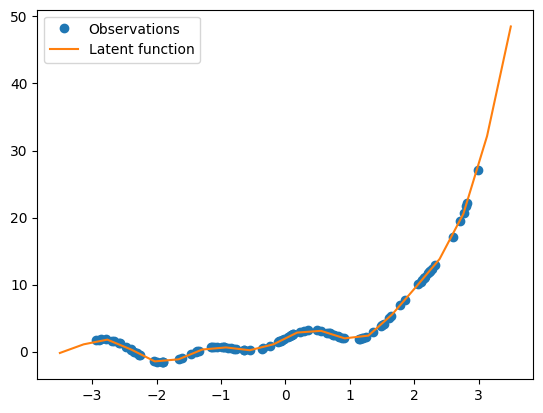

In [3]:
fig, ax = plt.subplots()
ax.plot(x, y, "o", label="Observations", color=cols[0])
ax.plot(xtest, ytest, label="Latent function", color=cols[1])
ax.legend(loc="best")

In [4]:
kernel = gpx.kernels.RBF()  # 1-dimensional input
meanf = gpx.mean_functions.Constant()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

ValueError: x and y must have same first dimension, but have shapes (20, 1) and (1,)

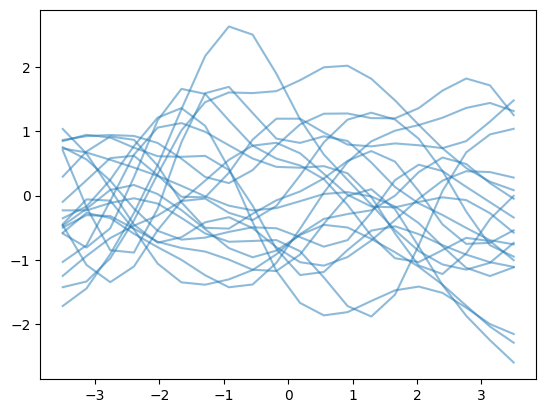

In [7]:
prior_dist = prior.predict(xtest)

prior_mean = prior_dist.mean
prior_std = prior_dist.variance
samples = prior_dist.sample(seed=key, sample_shape=(20,))


fig, ax = plt.subplots()
ax.plot(xtest, samples.T, alpha=0.5, color=cols[0], label="Prior samples")
ax.plot(xtest, prior_mean, color=cols[1], label="Prior mean")
ax.fill_between(
    xtest.flatten(),
    prior_mean - prior_std,
    prior_mean + prior_std,
    alpha=0.3,
    color=cols[1],
    label="Prior variance",
)

In [ ]:
likelihood = gpx.likelihoods.Gaussian(num_datapoints=D.n)

In [ ]:
posterior = prior * likelihood

In [ ]:
opt_posterior, history = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=D,
    trainable=gpx.parameters.Parameter,
)

print(-gpx.objectives.conjugate_mll(opt_posterior, D))

In [ ]:
opt_posterior

In [ ]:
latent_dist = opt_posterior.predict(xtest, train_data=D)
predictive_dist = opt_posterior.likelihood(latent_dist)

predictive_mean = predictive_dist.mean
predictive_std = jnp.sqrt(predictive_dist.variance)

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 2.5))
ax.plot(x, y, "x", label="Observations", color=cols[0], alpha=0.5)
ax.fill_between(
    xtest.squeeze(),
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    label="Two sigma",
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_mean - 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_mean + 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest, ytest, label="Latent function", color=cols[0], linestyle="--", linewidth=2
)
ax.plot(xtest, predictive_mean, label="Predictive mean", color=cols[1])
ax.legend(loc="center left", bbox_to_anchor=(0.975, 0.5))

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.optimize import root

def solve_plane_stress_uniaxial(stress_fun, lambda1):
    """
    Solve for lambda2, lambda3 such that sigma_33 = 0
    under uniaxial stretch along direction 1.
    """

    def residual(l23):
        lambda2, lambda3 = l23
        F = jnp.diag(jnp.array([lambda1, lambda2, lambda3]))

        sigma = stress_fun(F)  # user-supplied Cauchy stress fun

        return jnp.array([sigma[2, 2]])  # plane-stress: sigma_33 = 0

    # initial guesses (isochoric guess works well)
    l23_init = jnp.array([1.0 / jnp.sqrt(lambda1), 1.0 / jnp.sqrt(lambda1)])

    sol = root(residual, l23_init, method="hybr")
    lambda2, lambda3 = sol.x
    return lambda2, lambda3


In [ ]:
from core.datasetclass import *
from core.material_models import get_material

In [ ]:
unigen = UniaxialGenerator(1, (2.0, 2.0), 0, 0, get_material("neo-hookean"))

In [ ]:
f = unigen.get_F()

In [ ]:
stress_func = lambda f: unigen.get_cauchy_stress(f)

In [ ]:
stress_func(f)

In [ ]:
import jax
import jax.numpy as jnp
from scipy.optimize import root

def solve_plane_stress_uniaxial(stress_fun, lambda1):
    """
    Solve for lambda2, lambda3 such that sigma_33 = 0
    under uniaxial stretch along direction 1.
    """

    def residual(l23):
        lambda2, lambda3 = l23
        F = jnp.diag(jnp.array([lambda1, lambda2, lambda3]))[None, ...]

        sigma = stress_fun(F)[0]  # user-supplied Cauchy stress fun
        return jnp.array([sigma[1, 1], sigma[2, 2]])  # plane-stress: sigma_33 = 0

    # initial guesses (isochoric guess works well)
    l23_init = jnp.array([1.0 / jnp.sqrt(lambda1), 1.0 / jnp.sqrt(lambda1)])

    sol = root(residual, l23_init, method="hybr")
    lambda2, lambda3 = sol.x
    return lambda2, lambda3


In [ ]:
solve_plane_stress_uniaxial(stress_func, 2.0)

In [ ]:
stress_func(jnp.diag(jnp.array([2, 0.7925215553428202, 0.7925215553428202]))[None])

In [ ]:
def residual(stress_fun, l123):
    lambda1, lambda2, lambda3 = l123
    F = jnp.diag(jnp.array([lambda1, lambda2, lambda3]))[None, ...]

    sigma = stress_fun(F)  # user-supplied Cauchy stress fun
    
    return jnp.array([sigma[2, 2]])  # plane-stress: sigma_33 = 0

In [ ]:
residual(stress_func, jnp.array([2.0, 1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)]))